# Phase 3 RF-QRC tail probe — clean runner

Purpose: run the scripted RF-QRC tail probe and save the two lightweight diagnostic figures used to motivate the ring variant.

This notebook is intentionally minimal. The implementation lives in `scripts/run_phase3_rf_qrc_tail_probe.py`.

In [1]:
from pathlib import Path
import subprocess
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
EXPECTED_REPO_NAME = "qpitome-qrc-volatility"

def find_repo_root():
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if p.name == EXPECTED_REPO_NAME and (p / ".git").exists() and (p / "scripts").is_dir():
            return p
    raise RuntimeError(f"Could not find repo root named {EXPECTED_REPO_NAME!r} from {cwd}")

ROOT = find_repo_root()
TABLE_DIR = ROOT / "results" / "tables"
FIG_DIR = ROOT / "results" / "figures"
TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Repo root:", ROOT)
print("Tables:", TABLE_DIR)
print("Figures:", FIG_DIR)

Repo root: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility
Tables: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables
Figures: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures


## 1. Run scripted probe

In [2]:
cmd = [sys.executable, "scripts/run_phase3_rf_qrc_tail_probe.py", "--input-mode", "level_rate"]
print("$", " ".join(cmd))
result = subprocess.run(cmd, cwd=ROOT, text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
print(result.stdout)
if result.returncode != 0:
    raise RuntimeError(f"Probe failed with exit code {result.returncode}")

$ /opt/anaconda3/envs/qrc-volatility/bin/python scripts/run_phase3_rf_qrc_tail_probe.py --input-mode level_rate
Project root: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility
Dataset: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/data/processed/phase2_spy_vix_volatility.csv
Running rf_qrc_single_encode (level_rate, all_pairs)
Running rf_qrc_second_encode (level_rate, all_pairs)
Running rf_qrc_second_encode_ring (level_rate, ring)

Saved:
/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_tail_probe_metrics_level_rate.csv
/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_tail_probe_predictions_level_rate.csv
/Users/claudia/Documents/Documents - Cl

## 2. Load outputs

In [3]:
metrics_path = TABLE_DIR / "phase3_rf_qrc_tail_probe_metrics_level_rate.csv"
preds_path = TABLE_DIR / "phase3_rf_qrc_tail_probe_predictions_level_rate.csv"
summary_path = TABLE_DIR / "phase3_rf_qrc_tail_probe_test_summary_level_rate.csv"

metrics = pd.read_csv(metrics_path)
preds = pd.read_csv(preds_path, parse_dates=["date"])
summary = pd.read_csv(summary_path)
print(metrics_path)
print(preds_path)
print(summary_path)
display(summary)

/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_tail_probe_metrics_level_rate.csv
/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_tail_probe_predictions_level_rate.csv
/Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_tail_probe_test_summary_level_rate.csv


,run_name,split,n,rmse,qlike,corr,actual_mean,actual_std,pred_mean,pred_std,effective_rank,q90_actual_rate,q90_pred_rate,q90_f1,q90_precision,q90_recall,q95_actual_rate,q95_pred_rate,q95_f1,q95_precision,q95_recall,top20_actual_mean,top20_pred_mean,top20_pred_actual_ratio
0,rf_qrc_single_encode_level_rate,test,1136,0.128315,-0.598348,0.430179,0.178373,0.122736,0.113709,0.050164,7.097886,0.114437,0.025528,0.201258,0.551724,0.123077,0.044894,0.006162,0.000000,0.000000,0.000000,0.347153,0.148842,0.428749
1,rf_qrc_second_encode_level_rate,test,1136,0.120873,-0.668460,0.499179,0.178373,0.122736,0.122204,0.049225,8.503955,0.114437,0.037852,0.254335,0.511628,0.169231,0.044894,0.007923,0.166667,0.555556,0.098039,0.347153,0.162310,0.467545
2,rf_qrc_second_encode_ring_level_rate,test,1136,0.126830,-0.504768,0.556245,0.178373,0.122736,0.103069,0.064820,10.926582,0.114437,0.044894,0.320442,0.568627,0.223077,0.044894,0.021127,0.320000,0.500000,0.235294,0.347153,0.167448,0.482347


## 3. Progression figure

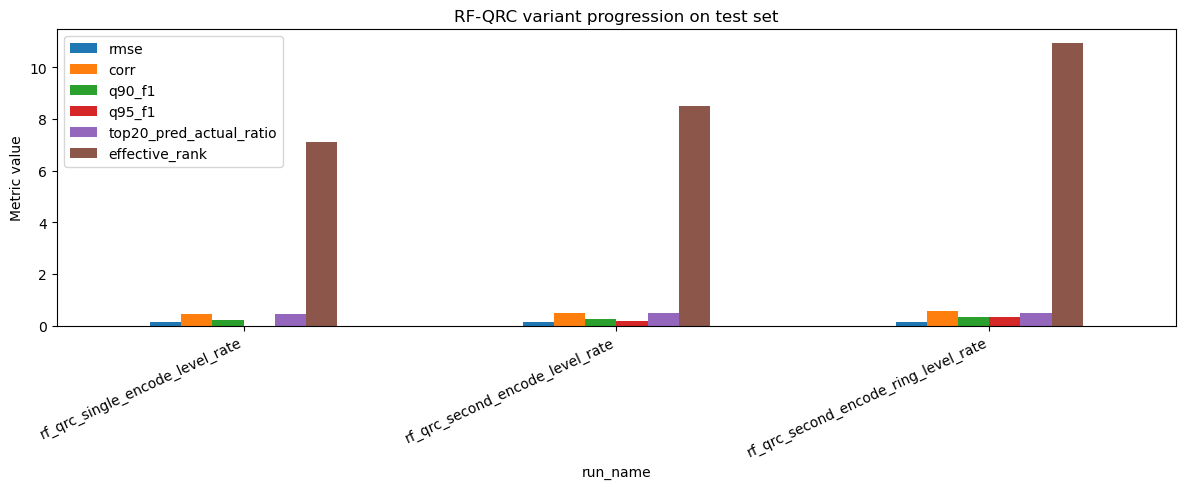

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_reservoir_progress_metrics.png


In [4]:
test_metrics = metrics[metrics["split"].eq("test")].copy()
plot_cols = ["rmse", "corr", "q90_f1", "q95_f1", "top20_pred_actual_ratio", "effective_rank"]
plot_df = test_metrics.set_index("run_name")[plot_cols]
ax = plot_df.plot(kind="bar", figsize=(12, 5))
ax.set_title("RF-QRC variant progression on test set")
ax.set_ylabel("Metric value")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
out = FIG_DIR / "phase3_rf_qrc_reservoir_progress_metrics.png"
plt.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

## 4. Forecast progression and tail thresholds

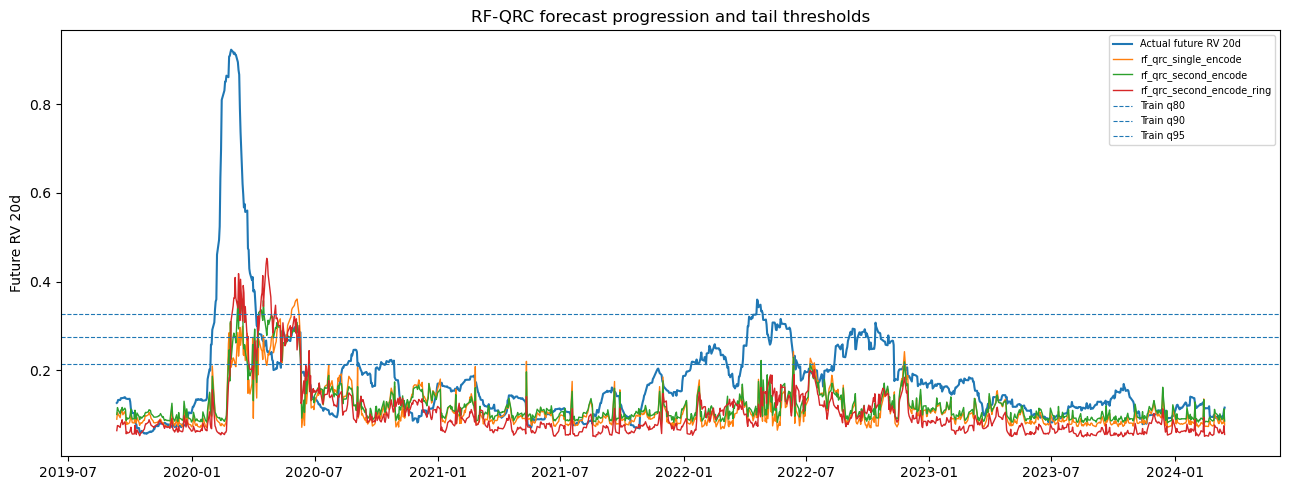

Saved: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_forecast_progression_tail_calibration.png


In [5]:
test = preds[preds["split"].eq("test")].copy()
train = preds[preds["split"].eq("train")].copy()
actual_col = "actual_future_rv_20d"
q80, q90, q95 = [float(train[actual_col].quantile(q)) for q in [0.80, 0.90, 0.95]]

pred_cols = [c for c in test.columns if c.endswith("_pred")]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(test["date"], test[actual_col], label="Actual future RV 20d", linewidth=1.5)
for c in pred_cols:
    ax.plot(test["date"], test[c], label=c.replace("_level_rate_pred", ""), linewidth=1.0)
for label, thr in [("q80", q80), ("q90", q90), ("q95", q95)]:
    ax.axhline(thr, linestyle="--", linewidth=0.8, label=f"Train {label}")
ax.set_title("RF-QRC forecast progression and tail thresholds")
ax.set_ylabel("Future RV 20d")
ax.legend(loc="upper right", fontsize=7)
fig.tight_layout()
out = FIG_DIR / "phase3_rf_qrc_forecast_progression_tail_calibration.png"
fig.savefig(out, dpi=200)
plt.show()
print("Saved:", out)

## 5. Saved outputs

In [7]:
print("Saved tables:")
for p in [metrics_path, preds_path, summary_path]:
    print(" ", p)
print("Saved figures:")
for name in [
    "phase3_rf_qrc_reservoir_progress_metrics.png",
    "phase3_rf_qrc_forecast_progression_tail_calibration.png",
]:
    print(" ", FIG_DIR / name)

Saved tables:
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_tail_probe_metrics_level_rate.csv
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_tail_probe_predictions_level_rate.csv
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_rf_qrc_tail_probe_test_summary_level_rate.csv
Saved figures:
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_reservoir_progress_metrics.png
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_rf_qrc_forecast_progression_tail_calibration.png
